<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113


Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
[InceptionNet v3] Epoch   1/100 | LR: 2.85e-04 | train loss 1.3792 acc 0.611 | val loss 0.9471 acc 0.384 *


Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113


Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
[InceptionNet v3] Epoch   2/100 | LR: 2.85e-04 | train loss 1.1963 acc 0.664 | val loss 0.9448 acc 0.656 *


Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113


...

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
[InceptionNet v3] Epoch  37/100 | LR: 2.85e-05 | train loss 0.2742 acc 0.938 | val loss 0.5086 acc 0.828


Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113


Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
[InceptionNet v3] Epoch  38/100 | LR: 2.85e-05 | train loss 0.2718 acc 0.940 | val loss 0.5492 acc 0.816


Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113


Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
[InceptionNet v3] Epoch  39/100 | LR: 2.85e-05 | train loss 0.2511 acc 0.942 | val loss 0.5082 acc 0.838

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 39.

[InceptionNet v3] R

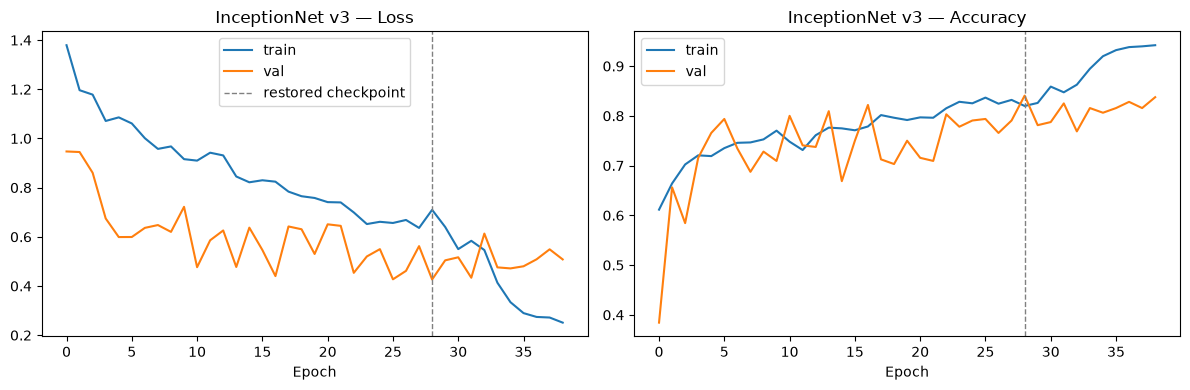

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113
[InceptionNet v3] Test accuracy: 0.655


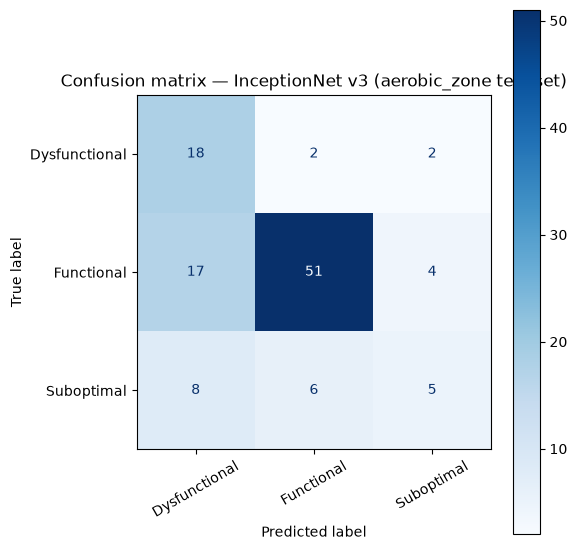

               precision    recall  f1-score   support

Dysfunctional      0.419     0.818     0.554        22
   Functional      0.864     0.708     0.779        72
   Suboptimal      0.455     0.263     0.333        19

     accuracy                          0.655       113
    macro avg      0.579     0.597     0.555       113
 weighted avg      0.709     0.655     0.660       113



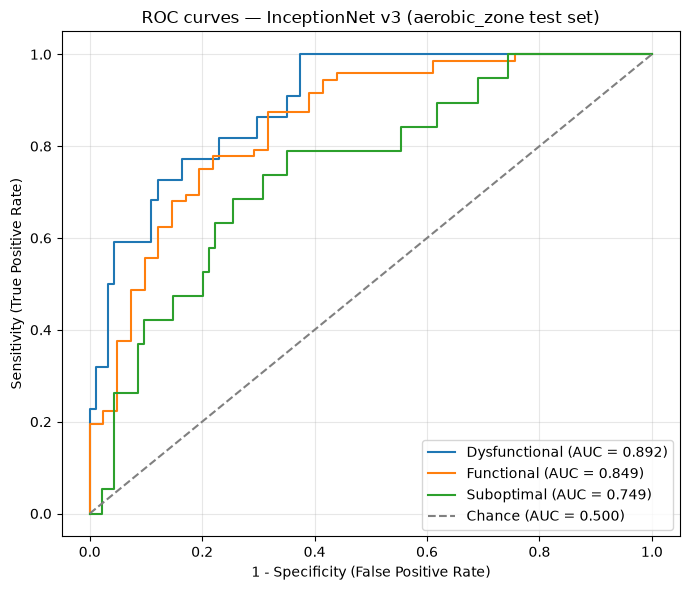

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.892
  Functional     : 0.849
  Suboptimal     : 0.749

Mean AUC (over 3/3 classes with test examples): 0.830


(np.float64(0.6548672566371682),
 {'Dysfunctional': 0.8921078921078921,
  'Functional': 0.8492547425474255,
  'Suboptimal': 0.7491601343784995})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/aerobic_zone_pad_aug/results_aerobic_zone_inception_v3_Atlantis.pkl
Saved model weights to ../models/pad/aerobic_zone_inception_v3_cnn.pt
